# Intelligent Patient Risk Assessment  
## Obesity Risk — Full Pipeline (Classification + Regression)

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score, precision_score, recall_score,
    mean_absolute_error, mean_squared_error, r2_score
)

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier

import joblib
import os

print("Libraries loaded")

Libraries loaded


In [3]:
from google.colab import files
import io

uploaded = files.upload()
file_name = list(uploaded.keys())[0]

df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print("Data loaded")
df.head()

Saving feature_engineered_data.csv to feature_engineered_data (1).csv
Data loaded


,Age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,obesity_risk_score,cholesterol_risk_score,high_bp_flag,bmi_age_interaction,combined_risk_index,age_group_middle,age_group_senior,bmi_category_obese,bmi_category_overweight,bmi_category_underweight
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,57.387241,51.492983,1,1769.0,52.994839,False,True,True,False,False
1,52,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,36.219202,3.984993,1,1201.2,27.620116,False,True,False,False,False
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,42.898797,21.793300,0,1332.0,40.128196,False,True,False,False,False
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,52.194082,22.962029,0,1983.2,49.950427,False,True,False,True,False
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,32.095465,34.296907,0,975.2,26.634294,True,False,False,False,False


In [5]:
print("Shape:", df.shape)
print("Columns:", len(df.columns))

Shape: (97297, 41)
Columns: 41


CLASSIFICATION PART

In [6]:
target_col = "obesity_risk_score"

df["target_class"] = pd.qcut(
    df[target_col],
    q=3,
    labels=[0,1,2],
    duplicates="drop"
)

df["target_class"].value_counts()

,count
target_class,
0,32433
2,32433
1,32431


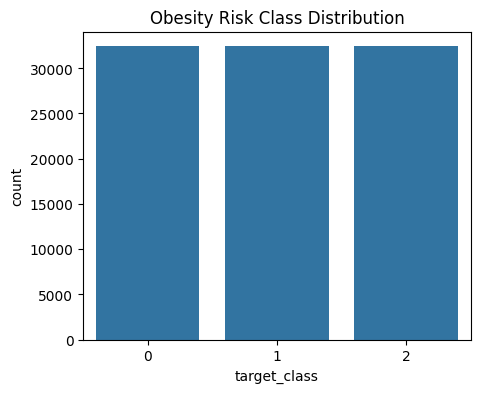

In [7]:
plt.figure(figsize=(5,4))
sns.countplot(x="target_class", data=df)
plt.title("Obesity Risk Class Distribution")
plt.show()

In [8]:
risk_cols = [
    "diabetes_risk_score",
    "heart_disease_risk_score",
    "hypertension_risk_score",
    "obesity_risk_score",
    "cholesterol_risk_score",
    "combined_risk_index"
]

existing = [c for c in risk_cols if c in df.columns]

X = df.drop(columns=existing + ["target_class"], errors="ignore")
y = df["target_class"]

print("Feature shape:", X.shape)

Feature shape: (97297, 35)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [10]:
X_all = pd.concat([X_train, X_test])

cat_cols = X_all.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    X_all = pd.get_dummies(X_all, columns=cat_cols, drop_first=True)

X_train = X_all.iloc[:len(X_train)]
X_test = X_all.iloc[len(X_train):]

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Logistic Regression

In [12]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

Decision Tree

In [13]:
dt_model = DecisionTreeClassifier(max_depth=6)
dt_model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=6)

In [14]:
def eval_cls(name, model, scaled=False):
    if scaled:
        preds = model.predict(X_test_scaled)
    else:
        preds = model.predict(X_test)

    acc = accuracy_score(y_test, preds)
    f1 = f1_score(y_test, preds, average="weighted")

    print(f"{name} → Accuracy: {acc:.4f}, F1: {f1:.4f}")

In [15]:
eval_cls("Logistic Regression", log_model, scaled=True)
eval_cls("Decision Tree", dt_model)

Logistic Regression → Accuracy: 0.9127, F1: 0.9129
Decision Tree → Accuracy: 0.8806, F1: 0.8819


In [16]:
best_cls_model = log_model
print("Best classification model: Logistic Regression")

Best classification model: Logistic Regression


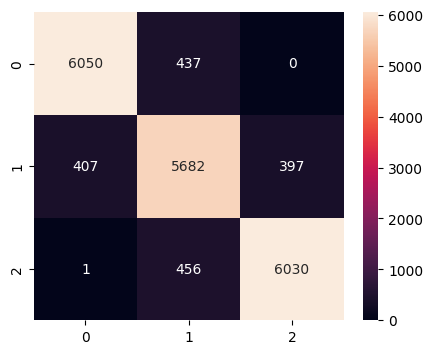

In [17]:
y_pred_cls = best_cls_model.predict(X_test_scaled)

plt.figure(figsize=(5,4))
sns.heatmap(confusion_matrix(y_test, y_pred_cls), annot=True, fmt="d")
plt.show()

In [18]:
print(classification_report(y_test, y_pred_cls))

              precision    recall  f1-score   support

           0       0.94      0.93      0.93      6487
           1       0.86      0.88      0.87      6486
           2       0.94      0.93      0.93      6487

    accuracy                           0.91     19460
   macro avg       0.91      0.91      0.91     19460
weighted avg       0.91      0.91      0.91     19460



In [19]:
precision = precision_score(y_test, y_pred_cls, average="weighted")
recall = recall_score(y_test, y_pred_cls, average="weighted")
f1 = f1_score(y_test, y_pred_cls, average="weighted")

print("Precision:", precision)
print("Recall:", recall)
print("F1:", f1)

Precision: 0.9130806460008102
Recall: 0.9127440904419322
F1: 0.9128906183718212


In [20]:
y_prob_cls = best_cls_model.predict_proba(X_test_scaled)

roc_auc = roc_auc_score(y_test, y_prob_cls, multi_class="ovr")
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.9852643237731451


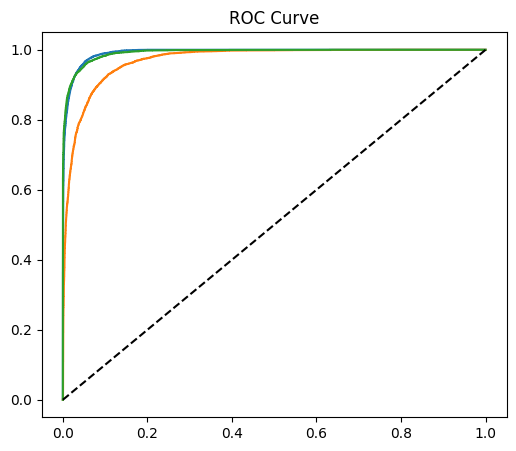

In [21]:
from sklearn.preprocessing import label_binarize

y_test_bin = label_binarize(y_test, classes=[0,1,2])

plt.figure(figsize=(6,5))

for i in range(3):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_cls[:, i])
    plt.plot(fpr, tpr)

plt.plot([0,1],[0,1],"k--")
plt.title("ROC Curve")
plt.show()

REGRESSION PART

In [22]:
y_reg = df[target_col]
X_reg = df.drop(columns=existing, errors="ignore")

In [23]:
Xr_train, Xr_test, yr_train, yr_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

In [24]:
Xr_all = pd.concat([Xr_train, Xr_test])

cat_cols = Xr_all.select_dtypes(include="object").columns

if len(cat_cols) > 0:
    Xr_all = pd.get_dummies(Xr_all, columns=cat_cols, drop_first=True)

Xr_train = Xr_all.iloc[:len(Xr_train)]
Xr_test = Xr_all.iloc[len(Xr_train):]

In [25]:
scaler_reg = StandardScaler()

Xr_train_scaled = scaler_reg.fit_transform(Xr_train)
Xr_test_scaled = scaler_reg.transform(Xr_test)

In [26]:
lin_reg = LinearRegression()
lin_reg.fit(Xr_train_scaled, yr_train)

LinearRegression()

In [27]:
yr_pred = lin_reg.predict(Xr_test_scaled)

In [28]:
mae = mean_absolute_error(yr_test, yr_pred)
mse = mean_squared_error(yr_test, yr_pred)
rmse = np.sqrt(mse)
r2 = r2_score(yr_test, yr_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("R2:", r2)

MAE: 1.4010010270356479
RMSE: 1.8153853455394398
R2: 0.9730911649689042


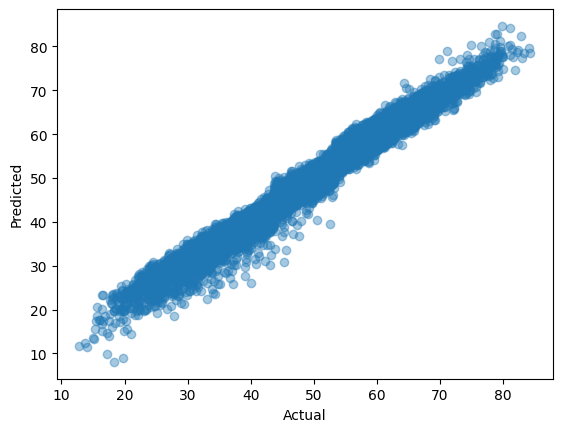

In [29]:
plt.scatter(yr_test, yr_pred, alpha=0.4)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()

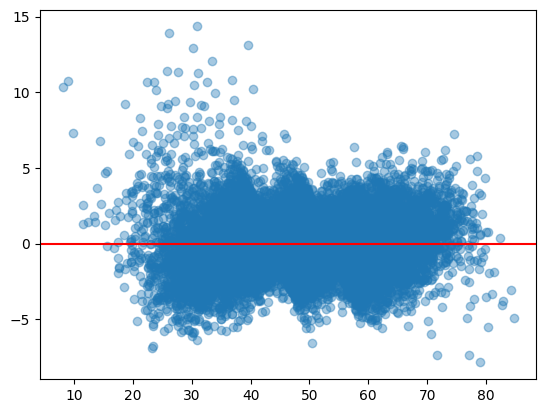

In [30]:
residuals = yr_test - yr_pred

plt.scatter(yr_pred, residuals, alpha=0.4)
plt.axhline(y=0, color="red")
plt.show()

In [31]:
scores = cross_val_score(lin_reg, Xr_train_scaled, yr_train, cv=5, scoring="r2")
print("CV R2:", scores.mean())

CV R2: 0.9730301031394679


In [32]:
coeffs = pd.Series(lin_reg.coef_, index=Xr_train.columns)
coeffs.sort_values(ascending=False).head(10)

,0
bmi,6.510656
waist_to_hip_ratio,2.546903
target_class,1.627507
screen_time_hours_per_day,0.666780
bmi_category_underweight,0.202291
bmi_category_obese,0.043652
cholesterol_total,0.020227
bmi_age_interaction,0.018195
systolic_bp,0.015660
glucose_fasting,0.012826


In [33]:
os.makedirs("models", exist_ok=True)

In [34]:
joblib.dump(lin_reg, "models/obesity_reg_model.pkl")

['models/obesity_reg_model.pkl']

In [35]:
joblib.dump(scaler_reg, "models/obesity_scaler.pkl")

['models/obesity_scaler.pkl']

In [36]:
joblib.dump(list(Xr_train.columns), "models/obesity_feature_cols.pkl")

['models/obesity_feature_cols.pkl']

In [37]:
print("Obesity Full Pipeline Completed Successfully!")

Obesity Full Pipeline Completed Successfully!


### Model Training Completed

Models trained:
- Logistic Regression  
- Decision Tree  
- Linear Regression  

Final selection:
- Logistic Regression for classification  
- Linear Regression for regression  